# Trilateration, GPS, and BLE RSSI — Exercise Solutions

This notebook solves the four exercises from the provided figure using Python. Mathematical formulas are written with `$...$` and `$$...$$` delimiters so that they render correctly in VS Code Markdown/KaTeX.

Sources used:

- `slidesTrilateration.pdf`
- `Blewitt Basics of gps.pdf`
- `BLE indoor positioning Bluetooth.pdf`

Main assumptions:

- Earth is a perfect sphere with $R_E = 6371$ km.
- Atmospheric and relativistic effects are ignored.
- The GPS satellite orbit is circular with radius $R_s$ measured from Earth's center.
- For BLE, RSSI is converted to distance using the log-distance model used in Bembenik and Falcman's paper.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

np.set_printoptions(precision=6, suppress=True)

## Exercise 1 — GPS minimum and maximum time of flight

Let the receiver radius from Earth's center be

$$r = R_E + h.$$

The shortest line of sight occurs when the satellite is directly above the receiver:

$$d_{\min} = R_s - r = R_s - R_E - h.$$

The longest visible line of sight occurs when the ray from receiver to satellite is tangent to the Earth. The tangent lengths from receiver and satellite to the tangent point add, so

$$d_{\max} = \sqrt{R_s^2 - R_E^2} + \sqrt{r^2 - R_E^2}.$$

This is equivalent to the expression in the exercise. Define

$$\beta = \cos^{-1}\left({R_E \over R_s}\right), \quad \phi = \sin^{-1}\left({R_E \over r}\right), \quad \psi = \cos^{-1}\left({R_E \over r}\right).$$

Then

$$d_{\max} = R_s {\sin(\psi + \beta) \over \sin \phi}.$$

Finally, time of flight is distance divided by the speed of light:

$$t_{\min} = {d_{\min} \over c}, \quad t_{\max} = {d_{\max} \over c}.$$

In [2]:
EARTH_RADIUS_KM = 6371.0
SPEED_OF_LIGHT_KM_S = 299_792.458


def gps_time_of_flight(R_s_km: float, h_km: float = 0.0, R_E_km: float = EARTH_RADIUS_KM) -> dict:
    """Return minimum and maximum GPS line-of-sight distances and times.

    Parameters
    ----------
    R_s_km:
        Circular satellite orbit radius measured from Earth's center, in km.
    h_km:
        Receiver height above Earth's surface, in km.
    R_E_km:
        Earth radius, in km.
    """
    r_km = R_E_km + h_km
    if R_s_km <= R_E_km:
        raise ValueError("Satellite orbit radius must be greater than Earth's radius.")
    if r_km < R_E_km:
        raise ValueError("Receiver radius must be at least Earth's radius.")

    d_min_km = R_s_km - r_km
    d_max_tangent_km = math.sqrt(R_s_km**2 - R_E_km**2) + math.sqrt(r_km**2 - R_E_km**2)

    beta = math.acos(R_E_km / R_s_km)
    phi = math.asin(R_E_km / r_km)
    psi = math.acos(R_E_km / r_km)
    d_max_angle_km = R_s_km * math.sin(psi + beta) / math.sin(phi)

    return {
        "receiver_radius_km": r_km,
        "d_min_km": d_min_km,
        "d_max_km": d_max_tangent_km,
        "d_max_angle_formula_km": d_max_angle_km,
        "t_min_s": d_min_km / SPEED_OF_LIGHT_KM_S,
        "t_max_s": d_max_tangent_km / SPEED_OF_LIGHT_KM_S,
        "angle_formula_difference_km": abs(d_max_tangent_km - d_max_angle_km),
    }


# Example using a nominal GPS orbital radius of about 26,600 km and a receiver on Earth's surface.
ex1 = gps_time_of_flight(R_s_km=26_600.0, h_km=0.0)
for key, value in ex1.items():
    print(f"{key:30s}: {value:.9f}")

receiver_radius_km            : 6371.000000000
d_min_km                      : 20229.000000000
d_max_km                      : 25825.769281863
d_max_angle_formula_km        : 25825.769281863
t_min_s                       : 0.067476681
t_max_s                       : 0.086145494
angle_formula_difference_km   : 0.000000000


For a nominal GPS orbit radius $R_s = 26{,}600$ km and a receiver on the surface, the result is about $67.48$ ms minimum and $86.15$ ms maximum. The angle formula and tangent-length formula match to numerical precision.

## Exercise 2 — Paris Charles de Gaulle to Rio de Janeiro/Galeão

We compute the great-circle distance using the haversine formula:

$$a = \sin^2\left({\Delta\varphi \over 2}\right) + \cos \varphi_1 \cos \varphi_2 \sin^2\left({\Delta\lambda \over 2}\right),$$

$$D = 2 R_E \sin^{-1}(\sqrt{a}).$$

Average ground speed is

$$v = {D \over T}.$$

For Earth rotation over a scheduled flight time $T$ in hours, using a 24-hour day as in the supplied answer,

$$\theta = 360^\circ {T \over 24}.$$

In [3]:
def haversine_distance_km(
    lat1_deg: float,
    lon1_deg: float,
    lat2_deg: float,
    lon2_deg: float,
    radius_km: float = EARTH_RADIUS_KM,
) -> float:
    """Great-circle distance on a sphere in km."""
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1_deg, lon1_deg, lat2_deg, lon2_deg])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2.0) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2.0) ** 2
    return 2.0 * radius_km * math.asin(math.sqrt(a))


# Airport coordinates used here:
# Charles de Gaulle (CDG): 49.0097 N, 2.5479 E
# Rio de Janeiro/Galeão (GIG): 22.8100 S, 43.2506 W
cdg = (49.0097, 2.5479)
gig = (-22.8100, -43.2506)
flight_time_h = 11.5

distance_km = haversine_distance_km(*cdg, *gig)
average_ground_speed_kmh = distance_km / flight_time_h
earth_rotation_deg = 360.0 * flight_time_h / 24.0

print(f"Great-circle distance:        {distance_km:.1f} km")
print(f"Average ground speed:         {average_ground_speed_kmh:.1f} km/h")
print(f"Earth rotation in 11.5 hours: {earth_rotation_deg:.1f} degrees")

Great-circle distance:        9183.9 km
Average ground speed:         798.6 km/h
Earth rotation in 11.5 hours: 172.5 degrees


The computed average ground speed is $798.6$ km/h, which rounds to $799$ km/h. Earth rotates $172.5^\circ$ in $11.5$ hours using a 24-hour day.

## Exercise 3 — Verification of Blewitt's design matrix $A$

Blewitt's pseudorange model for satellite $j$ can be written as

$$P_j = \rho_j(x,y,z) + c\tau - c\tau_j,$$

where

$$\rho_j(x,y,z) = \sqrt{(x^j - x)^2 + (y^j - y)^2 + (z^j - z)^2}.$$

Linearizing about provisional receiver coordinates $(x_0,y_0,z_0)$ gives row $j$ of the design matrix:

$$A_j = \begin{bmatrix}
{\partial P_j \over \partial x} & {\partial P_j \over \partial y} & {\partial P_j \over \partial z} & {\partial P_j \over \partial \tau}
\end{bmatrix}_{(x_0,y_0,z_0,\tau_0)}.$$

Since

$$ {\partial \rho_j \over \partial x} = {x_0 - x^j \over \rho_j}, \quad
{\partial \rho_j \over \partial y} = {y_0 - y^j \over \rho_j}, \quad
{\partial \rho_j \over \partial z} = {z_0 - z^j \over \rho_j}, \quad
{\partial P_j \over \partial \tau} = c,$$

Blewitt's matrix is correct, provided that each row uses its own range $\rho_j$ computed at the provisional receiver position.

In [4]:
SPEED_OF_LIGHT_M_S = 299_792_458.0
EARTH_RADIUS_M = EARTH_RADIUS_KM * 1000.0
GPS_RADIUS_M = 26_600_000.0


def pseudorange(receiver_xyz_m: np.ndarray, satellite_xyz_m: np.ndarray, receiver_clock_bias_s: float = 0.0) -> np.ndarray:
    """Ideal pseudorange to each satellite, ignoring satellite clock errors."""
    receiver_xyz_m = np.asarray(receiver_xyz_m, dtype=float)
    satellite_xyz_m = np.asarray(satellite_xyz_m, dtype=float)
    geometric_ranges = np.linalg.norm(satellite_xyz_m - receiver_xyz_m, axis=1)
    return geometric_ranges + SPEED_OF_LIGHT_M_S * receiver_clock_bias_s


def blewitt_design_matrix(receiver_guess_xyz_m: np.ndarray, satellite_xyz_m: np.ndarray) -> np.ndarray:
    """Design matrix A for GPS pseudorange point positioning.

    Columns are derivatives with respect to x, y, z, and receiver clock bias tau.
    """
    receiver_guess_xyz_m = np.asarray(receiver_guess_xyz_m, dtype=float)
    satellite_xyz_m = np.asarray(satellite_xyz_m, dtype=float)
    line_of_sight = receiver_guess_xyz_m - satellite_xyz_m
    rho = np.linalg.norm(line_of_sight, axis=1)
    spatial_part = line_of_sight / rho[:, None]
    clock_column = np.full((satellite_xyz_m.shape[0], 1), SPEED_OF_LIGHT_M_S)
    return np.hstack([spatial_part, clock_column])


def finite_difference_design_matrix(
    receiver_guess_xyz_m: np.ndarray,
    satellite_xyz_m: np.ndarray,
    dx_m: float = 1.0,
    dt_s: float = 1e-5,
) -> np.ndarray:
    """Numerically approximate the derivatives in A using central differences."""
    A_num = np.zeros((satellite_xyz_m.shape[0], 4))

    for col in range(3):
        perturb = np.zeros(3)
        perturb[col] = dx_m
        plus = pseudorange(receiver_guess_xyz_m + perturb, satellite_xyz_m)
        minus = pseudorange(receiver_guess_xyz_m - perturb, satellite_xyz_m)
        A_num[:, col] = (plus - minus) / (2.0 * dx_m)

    plus_tau = pseudorange(receiver_guess_xyz_m, satellite_xyz_m, receiver_clock_bias_s=dt_s)
    minus_tau = pseudorange(receiver_guess_xyz_m, satellite_xyz_m, receiver_clock_bias_s=-dt_s)
    A_num[:, 3] = (plus_tau - minus_tau) / (2.0 * dt_s)
    return A_num


# Four sample satellite directions, scaled to a nominal GPS orbital radius.
unit_directions = np.array([
    [0.80, 0.20, 0.56],
    [-0.35, 0.88, 0.32],
    [0.15, -0.73, 0.67],
    [-0.78, -0.30, 0.55],
], dtype=float)
unit_directions = unit_directions / np.linalg.norm(unit_directions, axis=1)[:, None]
satellites_m = GPS_RADIUS_M * unit_directions
receiver_guess_m = np.array([EARTH_RADIUS_M / math.sqrt(2.0), 0.0, EARTH_RADIUS_M / math.sqrt(2.0)])

A_analytic = blewitt_design_matrix(receiver_guess_m, satellites_m)
A_numeric = finite_difference_design_matrix(receiver_guess_m, satellites_m)
max_abs_error = np.max(np.abs(A_analytic - A_numeric))

print("Analytic A:")
print(A_analytic)
print("\nFinite-difference A:")
print(A_numeric)
print(f"\nMaximum absolute difference: {max_abs_error:.6e}")

Analytic A:
[[-8.207459e-01 -2.600660e-01 -5.086667e-01  2.997925e+08]
 [ 5.027833e-01 -8.520097e-01 -1.459059e-01  2.997925e+08]
 [ 2.228192e-02  8.246796e-01 -5.651611e-01  2.997925e+08]
 [ 8.906916e-01  2.814380e-01 -3.570170e-01  2.997925e+08]]

Finite-difference A:
[[-8.207459e-01 -2.600660e-01 -5.086667e-01  2.997925e+08]
 [ 5.027833e-01 -8.520097e-01 -1.459059e-01  2.997925e+08]
 [ 2.228192e-02  8.246796e-01 -5.651611e-01  2.997925e+08]
 [ 8.906916e-01  2.814380e-01 -3.570170e-01  2.997925e+08]]

Maximum absolute difference: 3.409386e-05


The finite-difference check confirms the analytic partial derivatives. The large value in the last column is expected because the fourth parameter is a clock bias in seconds, so the derivative is the speed of light $c$ in m/s.

## Exercise 4 — Optimization-based BLE RSSI positioning in a $5 \times 10$ m room

Bembenik and Falcman use a log-distance RSSI model of the form

$$RSSI_i = A_i - 10\gamma \log_{10}(d_i),$$

with inverse

$$\hat d_i = 10^{(A_i - RSSI_i)/(10\gamma)}.$$

The distance from a candidate receiver position $p = (x,y)$ to beacon $i$ at $b_i = (x_i,y_i)$ is

$$r_i(p) = \sqrt{(x-x_i)^2 + (y-y_i)^2}.$$

The optimization problem is the nonlinear least-squares multilateration problem

$$\min_{x,y} \sum_i \left(r_i(x,y) - \hat d_i\right)^2.$$

The exercise gives $\gamma = 1.74$ and $f = 2.45$ GHz. The paper's measured-power parameter $A_i$ is the RSSI at $1$ m. Since no beacon-specific measured power is given in the exercise, the code below computes a physically consistent default from free-space path loss at $1$ m:

$$A = -10\gamma \log_{10}\left({4\pi f \over c}\right).$$

You can replace this value with beacon calibration data if available.

In [5]:
@dataclass(frozen=True)
class RSSIModel:
    """Log-distance RSSI model.

    tx_power_db_at_1m is the A parameter in RSSI = A - 10*gamma*log10(d).
    If A is not provided, it is computed from free-space path loss at 1 m.
    """

    gamma: float = 1.74
    frequency_hz: float = 2.45e9
    speed_of_light_m_s: float = SPEED_OF_LIGHT_M_S
    tx_power_db_at_1m: Optional[float] = None

    @property
    def A(self) -> float:
        if self.tx_power_db_at_1m is not None:
            return float(self.tx_power_db_at_1m)
        return -10.0 * self.gamma * math.log10(4.0 * math.pi * self.frequency_hz / self.speed_of_light_m_s)

    def rssi_from_distance(self, distance_m: np.ndarray, noise_std_db: float = 0.0, rng: Optional[np.random.Generator] = None) -> np.ndarray:
        distance_m = np.maximum(np.asarray(distance_m, dtype=float), 1e-9)
        rssi = self.A - 10.0 * self.gamma * np.log10(distance_m)
        if noise_std_db > 0.0:
            if rng is None:
                rng = np.random.default_rng()
            rssi = rssi + rng.normal(0.0, noise_std_db, size=distance_m.shape)
        return rssi

    def distance_from_rssi(self, rssi_db: np.ndarray) -> np.ndarray:
        rssi_db = np.asarray(rssi_db, dtype=float)
        return 10.0 ** ((self.A - rssi_db) / (10.0 * self.gamma))


def distances_to_beacons(point_xy: np.ndarray, beacons_xy: np.ndarray) -> np.ndarray:
    """Euclidean distances from a point to every beacon."""
    point_xy = np.asarray(point_xy, dtype=float)
    beacons_xy = np.asarray(beacons_xy, dtype=float)
    return np.linalg.norm(beacons_xy - point_xy, axis=1)


def estimate_position_from_rssi(
    rssi_db: np.ndarray,
    beacons_xy: np.ndarray,
    model: RSSIModel,
    initial_guess_xy: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, np.ndarray, least_squares]:
    """Estimate 2D position from RSSI by nonlinear least squares."""
    beacons_xy = np.asarray(beacons_xy, dtype=float)
    measured_distances_m = model.distance_from_rssi(rssi_db)

    if initial_guess_xy is None:
        initial_guess_xy = np.mean(beacons_xy, axis=0)
    initial_guess_xy = np.asarray(initial_guess_xy, dtype=float)

    def residuals(point_xy: np.ndarray) -> np.ndarray:
        return distances_to_beacons(point_xy, beacons_xy) - measured_distances_m

    result = least_squares(residuals, initial_guess_xy, method="lm", max_nfev=200)
    return result.x, measured_distances_m, result

In [6]:
# Room setup: 5 m wide and 10 m long, beacons at the four corners.
room_width_m = 5.0
room_length_m = 10.0
beacons = np.array([
    [0.0, 0.0],
    [room_width_m, 0.0],
    [room_width_m, room_length_m],
    [0.0, room_length_m],
])

model = RSSIModel(gamma=1.74, frequency_hz=2.45e9)
rng = np.random.default_rng(42)
true_position = np.array([2.0, 7.0])
noise_std_db = 2.0

true_distances = distances_to_beacons(true_position, beacons)
simulated_rssi = model.rssi_from_distance(true_distances, noise_std_db=noise_std_db, rng=rng)
estimated_position, rssi_distances, opt_result = estimate_position_from_rssi(simulated_rssi, beacons, model)
position_error = np.linalg.norm(estimated_position - true_position)

print(f"Model A value at 1 m: {model.A:.3f} dB")
print(f"True position:        {true_position}")
print(f"Estimated position:   {estimated_position}")
print(f"Position error:       {position_error:.3f} m")
print("\nBeacon table:")
for i, (beacon, d_true, rssi, d_hat) in enumerate(zip(beacons, true_distances, simulated_rssi, rssi_distances), start=1):
    print(f"  Beacon {i}: xy={beacon}, true d={d_true:6.3f} m, RSSI={rssi:7.3f} dB, RSSI-derived d={d_hat:6.3f} m")

Model A value at 1 m: -35.001 dB
True position:        [2. 7.]
Estimated position:   [1.379167 7.913568]
Position error:       1.105 m

Beacon table:
  Beacon 1: xy=[0. 0.], true d= 7.280 m, RSSI=-49.393 dB, RSSI-derived d= 6.716 m
  Beacon 2: xy=[5. 0.], true d= 7.616 m, RSSI=-52.423 dB, RSSI-derived d=10.029 m
  Beacon 3: xy=[ 5. 10.], true d= 4.243 m, RSSI=-44.421 dB, RSSI-derived d= 3.478 m
  Beacon 4: xy=[ 0. 10.], true d= 3.606 m, RSSI=-42.811 dB, RSSI-derived d= 2.811 m


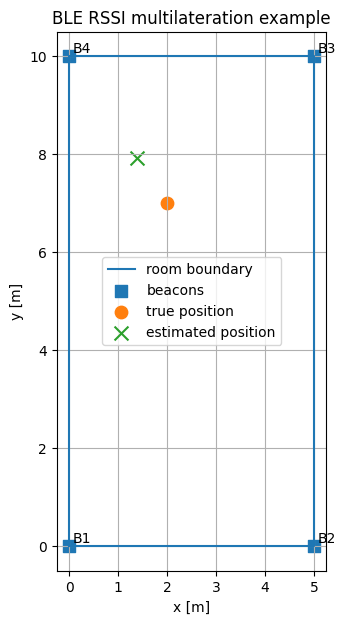

In [7]:
fig, ax = plt.subplots(figsize=(6, 7))
room_outline = np.array([[0, 0], [room_width_m, 0], [room_width_m, room_length_m], [0, room_length_m], [0, 0]])
ax.plot(room_outline[:, 0], room_outline[:, 1], label="room boundary")
ax.scatter(beacons[:, 0], beacons[:, 1], marker="s", s=80, label="beacons")
ax.scatter(true_position[0], true_position[1], marker="o", s=80, label="true position")
ax.scatter(estimated_position[0], estimated_position[1], marker="x", s=100, label="estimated position")
for i, beacon in enumerate(beacons, start=1):
    ax.text(beacon[0] + 0.08, beacon[1] + 0.08, f"B{i}")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("BLE RSSI multilateration example")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)
ax.legend()
plt.show()

### Monte Carlo noise test

The next cell samples random receiver positions in the room, adds Gaussian RSSI noise, and estimates the position. This gives a practical feel for the sensitivity of RSSI trilateration to signal noise.

In [8]:
def monte_carlo_ble_test(
    beacons_xy: np.ndarray,
    model: RSSIModel,
    n_trials: int = 500,
    noise_std_db: float = 2.0,
    room_width_m: float = 5.0,
    room_length_m: float = 10.0,
    seed: int = 123,
) -> dict:
    """Run random-position BLE multilateration trials in the room."""
    rng = np.random.default_rng(seed)
    true_positions = rng.uniform([0.0, 0.0], [room_width_m, room_length_m], size=(n_trials, 2))
    estimated_positions = np.zeros_like(true_positions)
    errors = np.zeros(n_trials)

    for k, true_xy in enumerate(true_positions):
        distances = distances_to_beacons(true_xy, beacons_xy)
        rssi = model.rssi_from_distance(distances, noise_std_db=noise_std_db, rng=rng)
        estimated_xy, _, _ = estimate_position_from_rssi(rssi, beacons_xy, model)
        estimated_positions[k] = estimated_xy
        errors[k] = np.linalg.norm(estimated_xy - true_xy)

    return {
        "true_positions": true_positions,
        "estimated_positions": estimated_positions,
        "errors": errors,
        "mean_error_m": float(np.mean(errors)),
        "median_error_m": float(np.median(errors)),
        "p90_error_m": float(np.percentile(errors, 90)),
        "max_error_m": float(np.max(errors)),
    }


mc = monte_carlo_ble_test(beacons, model, n_trials=500, noise_std_db=noise_std_db)
print(f"Trials:        {len(mc['errors'])}")
print(f"Mean error:    {mc['mean_error_m']:.3f} m")
print(f"Median error:  {mc['median_error_m']:.3f} m")
print(f"90th pctile:   {mc['p90_error_m']:.3f} m")
print(f"Max error:     {mc['max_error_m']:.3f} m")

Trials:        500
Mean error:    1.728 m
Median error:  1.509 m
90th pctile:   3.273 m
Max error:     7.016 m


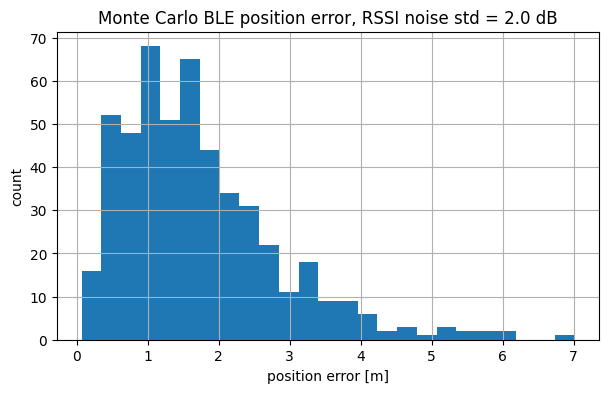

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(mc["errors"], bins=25)
ax.set_xlabel("position error [m]")
ax.set_ylabel("count")
ax.set_title(f"Monte Carlo BLE position error, RSSI noise std = {noise_std_db:.1f} dB")
ax.grid(True)
plt.show()

### Exercise 4 conclusion

With four corner beacons and exact RSSI values, the nonlinear least-squares estimator recovers the position to numerical precision. With $2$ dB RSSI noise, the example and Monte Carlo test show meter-level errors, which is consistent with the practical limitations discussed by Bembenik and Falcman: RSSI-derived ranges are noisy, and the position estimate improves when weak signals are filtered and multiple estimates are smoothed or averaged.

## Overall conclusions

1. The GPS time-of-flight result follows directly from tangent geometry and gives delays of only tens of milliseconds for nominal GPS satellite altitude.
2. The Paris-to-Rio flight distance from a spherical-Earth great circle gives an average ground speed of about $799$ km/h for an $11.5$ hour flight, and Earth rotates $172.5^\circ$ in the same interval.
3. Blewitt's GPS design matrix is correct: its spatial columns are line-of-sight direction cosines from satellite to receiver, and its clock-bias column is $c$.
4. BLE RSSI trilateration is straightforward to implement as nonlinear least squares, but it is highly sensitive to RSSI noise and calibration of $\gamma$ and $A$.